# **Machine Learning Assignment :- 8**

**   **
**Name: Harish Panpaliya**

**Class: CSAI-D**     

**Batch : 3**

**Roll No: 52**

**PRN: 12412173**

# Imported library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report



#Made Dataframe

In [ ]:
import pandas as pd

# Highly scrambled data to force model errors (False Positives and False Negatives)
data = {
    'CustomerID': range(101, 126),
    'Age': [25, 34, 45, 23, 50, 36, 22, 29, 40, 55, 31, 26, 48, 38, 27, 33, 42, 21, 52, 35, 28, 41, 58, 24, 46],
    'Income': [45000, 55000, 80000, 35000, 95000, 60000, 30000, 48000, 75000, 110000, 52000, 42000, 85000, 65000, 47000, 58000, 78000, 28000, 105000, 62000, 49000, 72000, 115000, 32000, 82000],
    'Previous_Purchases': [2, 5, 8, 1, 10, 6, 1, 3, 7, 12, 4, 2, 9, 6, 3, 5, 8, 0, 11, 5, 3, 7, 13, 1, 8],

    # Notice the heavy mixing of 0s and 1s regardless of the stats above
    'Offer_Accepted': [0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

print("Properly Scrambled Customer Dataset")
display(df.head())

Properly Scrambled Customer Dataset


,CustomerID,Age,Income,Previous_Purchases,Offer_Accepted
0,101,25,45000,2,0
1,102,34,55000,5,1
2,103,45,80000,8,0
3,104,23,35000,1,1
4,105,50,95000,10,1


# simple logistic regression on Income and offer-accepted

In [ ]:
X = df[['Income']]
y = df['Offer_Accepted']

# 3. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Scale the Single Feature
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train the Simple Logistic Regression Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 6. Make Predictions
y_pred = model.predict(X_test_scaled)

# 7. Evaluate using Manual Math
conf_matrix = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = conf_matrix.ravel()

total = TP + TN + FP + FN
accuracy = (TP + TN) / total if total > 0 else 0.0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print("--- Simple Logistic Regression (Income Only) ---")
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}\n")
print(f"TP: {TP} | TN: {TN} | FP: {FP} | FN: {FN}")

--- Simple Logistic Regression (Income Only) ---
Accuracy:  0.38
Precision: 0.29
Recall:    1.00
F1 Score:  0.44

TP: 2 | TN: 1 | FP: 5 | FN: 0


Heatmap saved successfully.


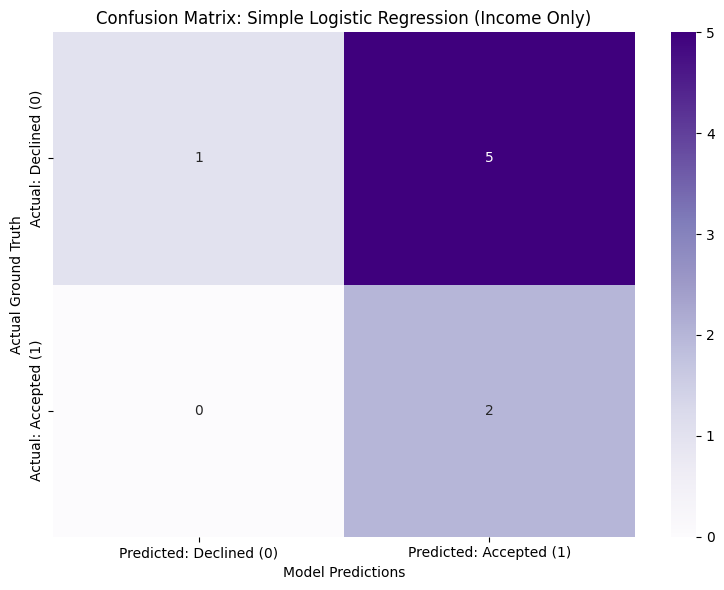

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted: Declined (0)', 'Predicted: Accepted (1)'],
            yticklabels=['Actual: Declined (0)', 'Actual: Accepted (1)'])

plt.title('Confusion Matrix: Simple Logistic Regression (Income Only)')
plt.xlabel('Model Predictions')
plt.ylabel('Actual Ground Truth')

plt.tight_layout()
plt.savefig('simple_logistic_heatmap.png')
print("Heatmap saved successfully.")

#multiple logistic regression on X=(Age,Income,Previous-purchase) and Offer-accepted

In [ ]:
X = df[['Age', 'Income', 'Previous_Purchases']]
y = df['Offer_Accepted']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# calculate parameters using builtin funtions

In [ ]:

conf_matrix = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = conf_matrix.ravel()


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)


print("\n--- Model Evaluation Results ---")
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}\n")

print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")


--- Model Evaluation Results ---
Accuracy:  0.38
Precision: 0.29
Recall:    1.00
F1 Score:  0.44

True Positives (TP): 2
True Negatives (TN): 1
False Positives (FP): 5
False Negatives (FN): 0


# calculate parameters using userdefined  funtions

In [ ]:
def get_confusion_matrix(y_true, y_pred):
    """Calculates True Positives, True Negatives, False Positives, False Negatives."""

    y_true = list(y_true)
    y_pred = list(y_pred)

    TN = FP = FN = TP = 0

    for actual, pred in zip(y_true, y_pred):
        if actual == 1 and pred == 1:
            TP += 1
        elif actual == 0 and pred == 0:
            TN += 1
        elif actual == 0 and pred == 1:
            FP += 1
        elif actual == 1 and pred == 0:
            FN += 1

    return TN, FP, FN, TP

def get_accuracy(TN, FP, FN, TP):
    total = TP + TN + FP + FN
    return (TP + TN) / total if total > 0 else 0.0

def get_precision(TP, FP):
    # zero_division protection
    return TP / (TP + FP) if (TP + FP) > 0 else 0.0

def get_recall(TP, FN):
    # zero_division protection
    return TP / (TP + FN) if (TP + FN) > 0 else 0.0

def get_f1_score(precision, recall):
    # zero_division protection
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

In [ ]:

TN, FP, FN, TP = get_confusion_matrix(y_test, y_pred)


accuracy = get_accuracy(TN, FP, FN, TP)
precision = get_precision(TP, FP)
recall = get_recall(TP, FN)
f1 = get_f1_score(precision, recall)


print("\n--- Model Evaluation Results ---")
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}\n")

print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")


--- Model Evaluation Results ---
Accuracy:  0.38
Precision: 0.29
Recall:    1.00
F1 Score:  0.44

True Positives (TP): 2
True Negatives (TN): 1
False Positives (FP): 5
False Negatives (FN): 0


#confusion matrix for multiple logistic regression

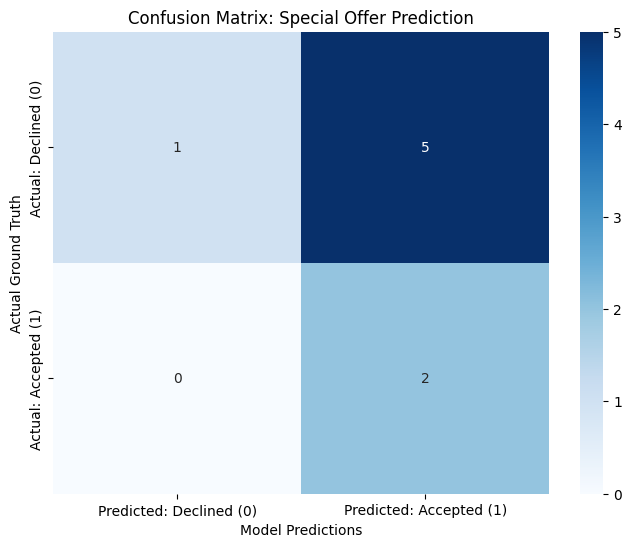

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 9. Visualize the Confusion Matrix using Seaborn
plt.figure(figsize=(8, 6))

# Create the heatmap
sns.heatmap(conf_matrix,
            annot=True,      # Prints the numbers inside the boxes
            fmt='d',         # Formats the numbers as whole integers
            cmap='Blues',    # Uses a blue color gradient
            xticklabels=['Predicted: Declined (0)', 'Predicted: Accepted (1)'],
            yticklabels=['Actual: Declined (0)', 'Actual: Accepted (1)'])

# Add labels and title for presentation
plt.title('Confusion Matrix: Special Offer Prediction')
plt.xlabel('Model Predictions')
plt.ylabel('Actual Ground Truth')

# Display the chart
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import confusion_matrix

# 1. The Dataset (Includes BOTH target columns)
data = {
    'CustomerID': range(101, 126),
    'Age': [25, 34, 45, 23, 50, 36, 22, 29, 40, 55, 31, 26, 48, 38, 27, 33, 42, 21, 52, 35, 28, 41, 58, 24, 46],
    'Income': [45000, 55000, 80000, 35000, 95000, 60000, 30000, 48000, 75000, 110000, 52000, 42000, 85000, 65000, 47000, 58000, 78000, 28000, 105000, 62000, 49000, 72000, 115000, 32000, 82000],
    'Previous_Purchases': [2, 5, 8, 1, 10, 6, 1, 3, 7, 12, 4, 2, 9, 6, 3, 5, 8, 0, 11, 5, 3, 7, 13, 1, 8],

    # Target 1 (y1)
    'Offer_Accepted': [0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1],

    # Target 2 (y2)
    'Joined_Loyalty': [0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1]
}
df = pd.DataFrame(data)

# 2. Select Multiple X and Multiple y
X = df[['Age', 'Income', 'Previous_Purchases']]
y = df[['Offer_Accepted', 'Joined_Loyalty']]

# 3. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Scale the X Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train the Multi-Output Model
base_model = LogisticRegression()
multi_model = MultiOutputClassifier(base_model)
multi_model.fit(X_train_scaled, y_train)

# 6. Make Predictions
y_pred = multi_model.predict(X_test_scaled)

# 7. Evaluate BOTH Targets and Calculate Parameters
y_test_numpy = y_test.to_numpy()

# --- Helper function for manual math ---
def get_metrics(TN, FP, FN, TP):
    total = TP + TN + FP + FN
    accuracy = (TP + TN) / total if total > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    return accuracy, precision, recall, f1

# --- Target 1: Offer Accepted ---
conf_matrix_1 = confusion_matrix(y_test_numpy[:, 0], y_pred[:, 0])
TN1, FP1, FN1, TP1 = conf_matrix_1.ravel()
acc1, prec1, rec1, f1_1 = get_metrics(TN1, FP1, FN1, TP1)

# --- Target 2: Joined Loyalty ---
conf_matrix_2 = confusion_matrix(y_test_numpy[:, 1], y_pred[:, 1])
TN2, FP2, FN2, TP2 = conf_matrix_2.ravel()
acc2, prec2, rec2, f1_2 = get_metrics(TN2, FP2, FN2, TP2)

# --- Print the Comparison Table ---
print("\n" + "="*50)
print(" MULTI-OUTPUT MODEL COMPARISON")
print("="*50)
print(f"{'Metric':<15} | {'Target 1 (Offer)':<15} | {'Target 2 (Loyalty)':<15}")
print("-" * 50)
print(f"{'Accuracy':<15} | {acc1:<15.2f} | {acc2:<15.2f}")
print(f"{'Precision':<15} | {prec1:<15.2f} | {prec2:<15.2f}")
print(f"{'Recall':<15} | {rec1:<15.2f} | {rec2:<15.2f}")
print(f"{'F1-Score':<15} | {f1_1:<15.2f} | {f1_2:<15.2f}")
print("-" * 50)
print(f"{'True Pos (TP)':<15} | {TP1:<15} | {TP2:<15}")
print(f"{'True Neg (TN)':<15} | {TN1:<15} | {TN2:<15}")
print(f"{'False Pos (FP)':<15} | {FP1:<15} | {FP2:<15}")
print(f"{'False Neg (FN)':<15} | {FN1:<15} | {FN2:<15}")
print("="*50)


 MULTI-OUTPUT MODEL COMPARISON
Metric          | Target 1 (Offer) | Target 2 (Loyalty)
--------------------------------------------------
Accuracy        | 0.38            | 0.62           
Precision       | 0.29            | 0.40           
Recall          | 1.00            | 1.00           
F1-Score        | 0.44            | 0.57           
--------------------------------------------------
True Pos (TP)   | 2               | 2              
True Neg (TN)   | 1               | 3              
False Pos (FP)  | 5               | 3              
False Neg (FN)  | 0               | 0              
